In [104]:
from datetime import datetime
import requests
import itertools

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
import pygad

# Toy example

In [105]:
prices = dict()
prices['A'] = np.array([1,0.5,1,1.5] * 20)
prices['B'] = np.ones_like(prices['A'])
print(prices)

{'A': array([1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. ,
       0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5,
       1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. ,
       1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5,
       1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. ,
       0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5, 1. , 1.5, 1. , 0.5,
       1. , 1.5]), 'B': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])}


In [5]:
returns = np.array([p[1:] / p[:-1] for s, p in prices.items()]).T
w = np.ones(2) / 2
np.cumprod(returns @ w)

array([ 0.75      ,  1.125     ,  1.40625   ,  1.171875  ,  0.87890625,
        1.31835938,  1.64794922,  1.37329102,  1.02996826,  1.54495239,
        1.93119049,  1.60932541,  1.20699406,  1.81049109,  2.26311386,
        1.88592821,  1.41444616,  2.12166924,  2.65208655,  2.21007213,
        1.65755409,  2.48633114,  3.10791393,  2.58992827,  1.9424462 ,
        2.91366931,  3.64208663,  3.03507219,  2.27630415,  3.41445622,
        4.26807027,  3.55672523,  2.66754392,  4.00131588,  5.00164485,
        4.16803738,  3.12602803,  4.68904205,  5.86130256,  4.8844188 ,
        3.6633141 ,  5.49497115,  6.86871394,  5.72392828,  4.29294621,
        6.43941932,  8.04927414,  6.70772845,  5.03079634,  7.54619451,
        9.43274314,  7.86061928,  5.89546446,  8.84319669, 11.05399586,
        9.21166322,  6.90874742, 10.36312112, 12.9539014 , 10.79491784,
        8.09618838, 12.14428257, 15.18035321, 12.65029434,  9.48772075,
       14.23158113, 17.78947641, 14.82456368, 11.11842276, 16.67

# Real stock data

In [7]:
start_date = '2010-01-01'
end_date = '2025-12-31'

In [8]:
sp_ticker = '^GSPC'

sp_data = yf.download(sp_ticker, start=start_date, end=end_date)['Close']
sp_daily_pct = sp_data.pct_change().dropna()

[*********************100%***********************]  1 of 1 completed


In [9]:
def get_sp500_tickers_by_date(target_date_str):
    target_date = pd.to_datetime(target_date_str)
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    
    # Standard headers are usually fine; Wikipedia just wants a non-empty User-Agent
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers)
    
    # 1. Get Tables
    tables = pd.read_html(response.text)
    df_current = tables[0]
    df_changes = tables[1]

    # 2. FLATTEN HEADERS
    # This turns ('Added', 'Ticker') into just 'Added_Ticker'
    df_changes.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df_changes.columns]
    
    # 3. Clean Date Column
    # The header usually becomes 'Date_Date' or 'Date_nan' after flattening
    date_col = [c for c in df_changes.columns if 'Date' in c][0]
    df_changes['Clean_Date'] = pd.to_datetime(df_changes[date_col], errors='coerce')

    current_tickers = set(df_current['Symbol'].tolist())

    # 4. Reverse Changes (Working backwards from today)
    relevant_changes = df_changes[df_changes['Clean_Date'] > target_date]

    for _, row in relevant_changes.iterrows():
        # Adjust these strings based on what the flattened headers actually are
        added = row.get('Added_Ticker')
        removed = row.get('Removed_Ticker')

        if pd.notna(added) and added in current_tickers:
            current_tickers.remove(added)
        if pd.notna(removed):
            current_tickers.add(removed)

    return sorted(list(current_tickers))

all_possible_tickers = set()
for year in range(2014, 2025):
    curr_tickers = get_sp500_tickers_by_date(
        target_date_str=f"{year - 1}-12-31")
    all_possible_tickers.update(curr_tickers)

# Run experiments

## Experimentation execution function

In [12]:
def select_stocks(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    num_stocks: int,
    pivot_mode: str,
    pivot_idx: int = 1
) -> list[str]:
    performance = df_train.cumprod().iloc[-1].sort_values(ascending=False)
    
    if pivot_mode == 'max':
        # pivot_idx=1 is the #1 performer, 2 is #2, etc.
        pivot_stock = performance.index[pivot_idx - 1]
        
    elif pivot_mode == 'min':
        # Picks from the bottom of the sorted list
        pivot_stock = performance.index[-pivot_idx]
        
    elif pivot_mode == 'median':
        # Picks the middle stock
        mid_idx = len(performance) // 2
        pivot_stock = performance.index[mid_idx]
        
    elif pivot_mode == 'quantile':
        # Picks based on a specific percentile (e.g., 0.75 for top 25%)
        quantile_val = pivot_idx / 100.0
        q_idx = int(len(performance) * (1 - quantile_val))
        # Ensure index is within bounds
        q_idx = min(max(q_idx, 0), len(performance) - 1)
        pivot_stock = performance.index[q_idx]
        
    else:
        # Default to the absolute top performer
        pivot_stock = performance.idxmax()
        
    selected_stocks = [pivot_stock]
    remaining = list(set(df_train.columns) - set(selected_stocks))

    corr_mat = df_train.corr().abs()
    for _ in range(num_stocks - 1):
        curr_corr = corr_mat.loc[selected_stocks, remaining]
        # Find stock with the lowest "max correlation" to the current set
        next_stock = curr_corr.max(axis=0).idxmin()
        selected_stocks.append(next_stock)
        remaining.remove(next_stock)
        
    return selected_stocks

In [60]:
def run_portfolio_experiment(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    num_stocks: int,
    fitness_type: str,
    ga_config: dict
):
    # 1. Fitness Function Wrapper
    def fitness_func(ga_instance, solution, solution_idx):
        weights = solution / np.sum(solution)
        port_ret = df_train @ weights
        
        if fitness_type == 'sharpe':
            mu = port_ret.mean()
            std = port_ret.std()
            return ((mu-1) / (std + 1e-9)) * np.sqrt(252)
        else:
            # Return Only
            return port_ret.mean() * 252

    # 2. Run GA
    num_generations = ga_config["num_generations"]
    sol_per_pop = ga_config["sol_per_pop"]
    num_parents_mating = ga_config["num_parents_mating"]
    mutation_num_genes = ga_config["mutation_num_genes"]
    crossover_type = ga_config["crossover_type"]
    stop_criteria = ga_config["stop_criteria"]
    
    ga = pygad.GA(
        num_generations=num_generations,
        sol_per_pop=sol_per_pop,
        num_parents_mating=num_parents_mating,
        mutation_num_genes=mutation_num_genes,
        crossover_type=crossover_type,
        stop_criteria=stop_criteria,
        fitness_func=fitness_func,
        num_genes=num_stocks,
        gene_space={'low': 0, 'high': 1},
        random_seed=42
    )
    ga.run()
    
    best_sol, _, _ = ga.best_solution()
    ga_weights = best_sol / np.sum(best_sol)

    # 3. Evaluate on Test Set (Cumulative Return)
    ga_daily_gross = df_test @ ga_weights
    ga_return = ga_daily_gross.prod()
    ga_daily_net = ga_daily_gross - 1
    ga_realized_sharpe = (ga_daily_net.mean() / ga_daily_net.std()) * np.sqrt(252)
    
    return {
        'ga_return': ga_return,
        'ga_realized_sharpe': ga_realized_sharpe,
        'selected_stocks': selected_stocks,
        'ga_weights': ga_weights
    }

## Pull all tickers data

In [63]:
len(all_possible_tickers)

705

In [65]:
# master_df_raw = yf.download(list(all_possible_tickers), start=start_date, end=end_date)

# master_df_close = master_df_raw['Close']
# master_df_clean = master_df_close.dropna(axis=1, how='any')
# master_df = (1 + master_df_clean.pct_change()).fillna(1)

In [67]:
master_df.shape

(4023, 482)

## Expirementation loop

In [70]:
def calculate_snp_500_metrics(
    sp_year_returns: pd.Series
) -> tuple[float, float]:
    # 1. Calculate Growth (Product)
    sp_total_growth = (sp_year_returns + 1).prod()
    
    # 2. Calculate daily stats for Sharpe
    # If sp_year_returns is a DataFrame, these will be Series. 
    # If it's a Series, these will be scalars.
    mu_raw = sp_year_returns.mean()
    std_raw = sp_year_returns.std()
    
    # 3. Handle extraction (ensures we have single floats, not Series)
    # This handles the case where Yahoo Finance returns a multi-index column
    sp_total_val = sp_total_growth.item() if hasattr(sp_total_growth, 'item') else sp_total_growth
    sp_mu_val = mu_raw.item() if hasattr(mu_raw, 'item') else mu_raw
    sp_std_val = std_raw.item() if hasattr(std_raw, 'item') else std_raw
    
    # 4. Final Sharpe Calculation
    sp_sharpe = (sp_mu_val / sp_std_val) * np.sqrt(252) if sp_std_val != 0 else 0

    return float(sp_total_val), float(sp_sharpe)

In [72]:
# Initial setup
num_stocks = 10
test_years = list(range(2015, 2026))
ga_objectives = ['sharpe', 'return']
pivot_mode = 'max'
pivot_idx = 1

num_stocks_to_ga_configs = {
    5: {
        "num_generations": 40,        # Fast convergence for small space
        "sol_per_pop": 40,           
        "num_parents_mating": 2,      # High selection pressure
        "mutation_num_genes": 1,      
        "crossover_type": "single_point",
        "stop_criteria": "saturate_10" # Stop if no improvement in 10 gens
    },
    10: {
        "num_generations": 100,
        "sol_per_pop": 80,
        "num_parents_mating": 8,
        "mutation_num_genes": 1,      # 10% mutation is standard
        "crossover_type": "two_points",
        "stop_criteria": "saturate_15"
    },
    15: {
        "num_generations": 150,
        "sol_per_pop": 120,
        "num_parents_mating": 12,
        "mutation_num_genes": 2,      
        "crossover_type": "uniform",   # Better for mixing more variables
        "stop_criteria": "saturate_20"
    },
    20: {
        "num_generations": 250,
        "sol_per_pop": 200,           # Wide search area needs more "explorers"
        "num_parents_mating": 20,
        "mutation_num_genes": 3,      
        "crossover_type": "uniform",
        "stop_criteria": "saturate_25"
    }
}

num_stocks_values = [5, 10, 15, 20]

pivot_tuples = [
    ('max', 1), ('max', 2), ('max', 3), ('max', 5), ('max', 10),
    ('median', 1),
    ('quantile', 10), ('quantile', 25), ('quantile', 75), ('quantile', 90)
]

In [74]:
experiment_id = 0

experiment_params_dict: dict[int, dict] = {}
experiment_results_dict: dict[int, pd.DataFrame] = {}

for num_stocks, (pivot_mode, pivot_idx) in itertools.product(num_stocks_values, pivot_tuples):
    experiment_params_dict[experiment_id] = {
        'num_stocks': num_stocks,
        'pivot_mode': pivot_mode,
        'pivot_idx': pivot_idx,
    }

    ga_config = num_stocks_to_ga_configs[num_stocks]
    
    results = []
    for test_year in test_years:
        # 1. Define expanding window
        train_end = f"{test_year - 1}-12-31"
        test_start = f"{test_year}-01-01"
        test_end = f"{test_year}-12-31"
        
        # print(f"--- Processing Test Year: {test_year} ---")
        # print(f"Training on: {start_date} to {train_end}")
    
        # 2. Get the current year's relevant tickers
        tickers_at_time = get_sp500_tickers_by_date(train_end)
        available = [t for t in tickers_at_time if t in master_df.columns]
        df_current_universe = master_df[available]
    
        # 3. Run S&P 500 benchmark
        sp_year_returns = sp_daily_pct.loc[test_start:test_end]
        sp_returns, sp_sharpe = calculate_snp_500_metrics(
            sp_year_returns=sp_year_returns)
        
        # 4. Create train & test data and select stocks
        df_train = df_current_universe.loc[start_date:train_end]
        df_test = df_current_universe.loc[test_start:test_end]
        selected_stocks = select_stocks(
            df_train=df_train,
            df_test=df_test,
            num_stocks=num_stocks,
            pivot_mode=pivot_mode,
            pivot_idx=pivot_idx,
        )
        
        train_stocks_df = df_train[selected_stocks]
        test_stocks_df = df_test[selected_stocks]
        test_port_returns = (test_stocks_df - 1) # assuming df is (1 + pct_change)
    
        # 5. Run uniform rebalancing
        uni_weights = np.array([1/num_stocks] * num_stocks)
        uni_daily_net = test_port_returns @ uni_weights
        uniform_realized_sharpe = (uni_daily_net.mean() / uni_daily_net.std()) * np.sqrt(252)
        uniform_final_return = (uni_daily_net + 1).prod()
        
        yearly_results = {
            'year': test_year,
            'uniform_returns': uniform_final_return,
            'sp500_returns': sp_returns,
            'uniform_realized_sharpe': uniform_realized_sharpe,
            'sp500_sharpe': sp_sharpe,
        }
        
        # 6. Run GA Optimizations
        for objective in ga_objectives:
            exp_res = run_portfolio_experiment(
                df_train=train_stocks_df,
                df_test=test_stocks_df,
                num_stocks=num_stocks,
                fitness_type=objective,
                ga_config=ga_config,
            )
    
            yearly_results[f"ga_{objective}_obj_returns"] = exp_res['ga_return']
            yearly_results[f"ga_{objective}_obj_sharpe"] = exp_res['ga_realized_sharpe']
    
        results.append(yearly_results)

    experiment_results_dict[experiment_id] = pd.DataFrame(results)
    print(f"Done with experiment {experiment_id}")
    experiment_id += 1

Done with experiment 0
Done with experiment 1
Done with experiment 2
Done with experiment 3
Done with experiment 4
Done with experiment 5
Done with experiment 6
Done with experiment 7
Done with experiment 8
Done with experiment 9
Done with experiment 10
Done with experiment 11
Done with experiment 12
Done with experiment 13
Done with experiment 14
Done with experiment 15
Done with experiment 16
Done with experiment 17
Done with experiment 18
Done with experiment 19
Done with experiment 20
Done with experiment 21
Done with experiment 22
Done with experiment 23
Done with experiment 24
Done with experiment 25
Done with experiment 26
Done with experiment 27
Done with experiment 28
Done with experiment 29
Done with experiment 30
Done with experiment 31
Done with experiment 32
Done with experiment 33
Done with experiment 34
Done with experiment 35
Done with experiment 36
Done with experiment 37
Done with experiment 38
Done with experiment 39


In [76]:
# # 1. Setup Data
# # Assuming results_df now has 'year' as index or column
# years = results_df['year'] if 'year' in results_df.columns else results_df.index
# x = np.arange(len(years))
# width = 0.2  # Width of each individual bar

# # 2. Setup Figure
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# # --- SUBPLOT 1: ANNUAL RETURNS ---
# # (Value - 1) * 100 converts growth factor (e.g., 1.10) to percentage (10%)
# ax1.bar(x - 1.5*width, (results_df['ga_return_obj_returns'] - 1)*100, width, label='GA (Opt: Return)', color='#1f77b4')
# ax1.bar(x - 0.5*width, (results_df['ga_sharpe_obj_returns'] - 1)*100, width, label='GA (Opt: Sharpe)', color='#aec7e8')
# ax1.bar(x + 0.5*width, (results_df['uniform_returns'] - 1)*100, width, label='Uniform', color='#ff7f0e')
# ax1.bar(x + 1.5*width, (results_df['sp500_returns'] - 1)*100, width, label='S&P 500', color='#2ca02c')

# ax1.set_title('Yearly Return (%) Comparison', fontsize=14, fontweight='bold')
# ax1.set_ylabel('Return (%)')
# ax1.set_xticks(x)
# ax1.set_xticklabels(years)
# ax1.legend()
# ax1.grid(axis='y', linestyle='--', alpha=0.7)

# # --- SUBPLOT 2: REALIZED SHARPE ---
# ax2.bar(x - 1.5*width, results_df['ga_return_obj_sharpe'], width, label='GA (Opt: Return)', color='#1f77b4')
# ax2.bar(x - 0.5*width, results_df['ga_sharpe_obj_sharpe'], width, label='GA (Opt: Sharpe)', color='#aec7e8')
# ax2.bar(x + 0.5*width, results_df['uniform_realized_sharpe'], width, label='Uniform', color='#ff7f0e')
# ax2.bar(x + 1.5*width, results_df['sp500_sharpe'], width, label='S&P 500', color='#2ca02c')

# ax2.set_title('Realized Sharpe Ratio Comparison', fontsize=14, fontweight='bold')
# ax2.set_ylabel('Annualized Sharpe')
# ax2.set_xticks(x)
# ax2.set_xticklabels(years)
# ax2.legend()
# ax2.grid(axis='y', linestyle='--', alpha=0.7)

# plt.tight_layout()
# plt.show()

In [250]:
print("sp500_total_growth                   3.349478")
print("sp500_avg_sharpe                  1.037969")

sp500_total_growth                   3.349478
sp500_avg_sharpe                  1.037969


In [96]:
all_results = []
for exp_id, results_df in experiment_results_dict.items():
    curr_results = {
        # 'exp_id': exp_id,
        'ga_model_return_opt_total_growth': results_df['ga_return_obj_returns'].prod(),
        'ga_model_sharpe_opt_total_growth': results_df['ga_sharpe_obj_returns'].prod(),
        'uniform_model_total_growth': results_df['uniform_returns'].prod(),
        # 'sp500_total_growth': results_df['sp500_returns'].prod(),
        'ga_model_return_opt_avg_sharpe': results_df['ga_return_obj_sharpe'].mean(),
        'ga_model_sharpe_opt_avg_sharpe': results_df['ga_sharpe_obj_sharpe'].mean(),
        'uniform_model_avg_sharpe': results_df['uniform_realized_sharpe'].mean(),
        # 'sp500_avg_sharpe': results_df['sp500_sharpe'].mean(),
    }
    all_results.append(curr_results)
final_results_df = pd.DataFrame(all_results)

In [98]:
final_results_df.shape

(40, 6)

In [138]:
experiment_results_dict[18]

,year,uniform_returns,sp500_returns,uniform_realized_sharpe,sp500_sharpe,ga_sharpe_obj_returns,ga_sharpe_obj_sharpe,ga_return_obj_returns,ga_return_obj_sharpe
0,2015,1.110214,0.992734,0.717132,0.030193,1.292830,1.682996,2.315582,1.926468
1,2016,1.149769,1.095350,0.903708,0.760950,1.001096,0.093258,1.086144,0.406136
2,2017,1.459373,1.194200,3.972999,2.699411,1.356556,3.807825,1.548261,1.762700
3,2018,0.990419,0.937627,0.044923,-0.293931,0.993239,0.072271,1.380881,0.938666
4,2019,1.325197,1.288781,1.607195,2.097391,1.371710,2.565073,1.219630,0.757432
5,2020,1.268949,1.162589,0.917944,0.609062,1.198803,0.715162,1.663522,1.347975
6,2021,1.195013,1.268927,1.632899,1.884257,1.247810,1.635590,1.119396,0.514030
7,2022,0.956317,0.805572,-0.059553,-0.777095,0.860810,-0.430324,0.496276,-0.642531
8,2023,1.172735,1.242305,1.158515,1.736286,1.151321,0.960496,1.637092,1.540848
9,2024,1.198490,1.233090,1.503787,1.720149,1.273979,1.790394,1.798969,2.171302


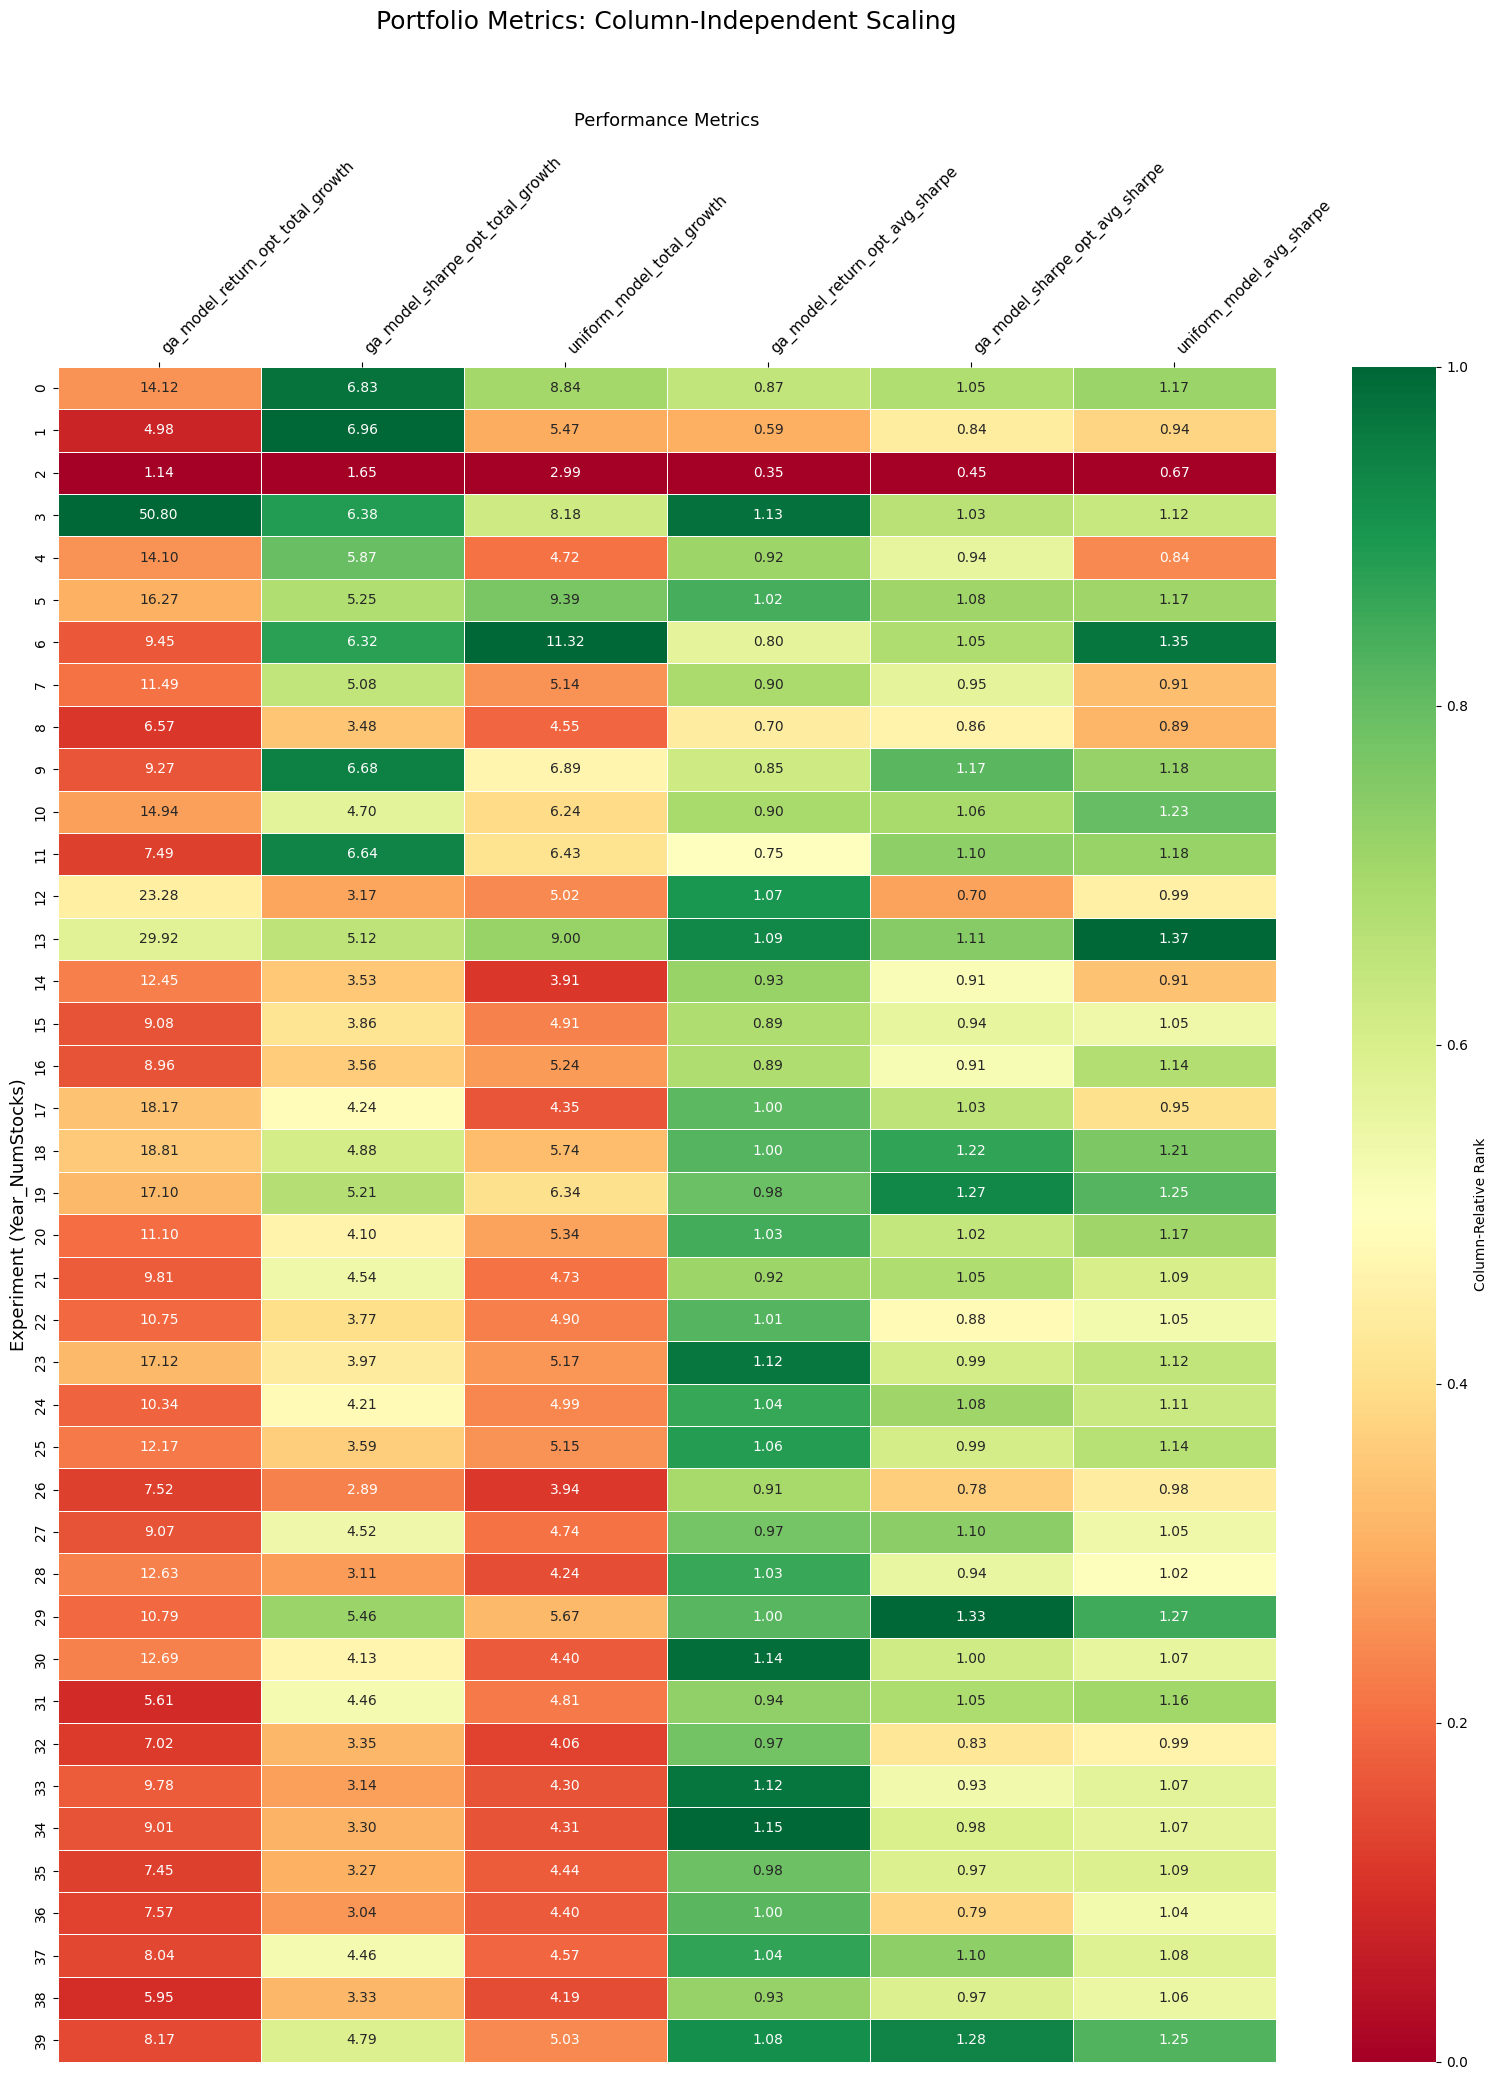

In [112]:
# 1. Prepare data (Independent Column Scaling)
df_numeric = final_results_df.copy()
df_norm = (df_numeric - df_numeric.min()) / (df_numeric.max() - df_numeric.min())

# 2. Setup Figure
plt.figure(figsize=(16, 22))

# 3. Create Heatmap
ax = sns.heatmap(
    df_norm, 
    annot=df_numeric, 
    fmt=".2f", 
    cmap="RdYlGn", 
    linewidths=0.5,
    cbar_kws={'label': 'Column-Relative Rank'}
)

# --- THE FIX: MOVE LABELS TO THE TOP ---
ax.xaxis.tick_top() # Move the ticks to the top
ax.xaxis.set_label_position('top') # Move the axis label ("Metrics") to the top

# Adjust rotation for top-aligned labels
# ha='left' works better when labels are at the top and angled
plt.xticks(rotation=45, ha='left', fontsize=11) 

plt.title("Portfolio Metrics: Column-Independent Scaling", fontsize=18, pad=60)
plt.ylabel("Experiment (Year_NumStocks)", fontsize=13)
plt.xlabel("Performance Metrics", fontsize=13, labelpad=20)

# Use tight_layout with a top pad to ensure the labels aren't cut off
plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.show()

In [116]:
experiment_params_dict

{0: {'num_stocks': 5, 'pivot_mode': 'max', 'pivot_idx': 1},
 1: {'num_stocks': 5, 'pivot_mode': 'max', 'pivot_idx': 2},
 2: {'num_stocks': 5, 'pivot_mode': 'max', 'pivot_idx': 3},
 3: {'num_stocks': 5, 'pivot_mode': 'max', 'pivot_idx': 5},
 4: {'num_stocks': 5, 'pivot_mode': 'max', 'pivot_idx': 10},
 5: {'num_stocks': 5, 'pivot_mode': 'median', 'pivot_idx': 1},
 6: {'num_stocks': 5, 'pivot_mode': 'quantile', 'pivot_idx': 10},
 7: {'num_stocks': 5, 'pivot_mode': 'quantile', 'pivot_idx': 25},
 8: {'num_stocks': 5, 'pivot_mode': 'quantile', 'pivot_idx': 75},
 9: {'num_stocks': 5, 'pivot_mode': 'quantile', 'pivot_idx': 90},
 10: {'num_stocks': 10, 'pivot_mode': 'max', 'pivot_idx': 1},
 11: {'num_stocks': 10, 'pivot_mode': 'max', 'pivot_idx': 2},
 12: {'num_stocks': 10, 'pivot_mode': 'max', 'pivot_idx': 3},
 13: {'num_stocks': 10, 'pivot_mode': 'max', 'pivot_idx': 5},
 14: {'num_stocks': 10, 'pivot_mode': 'max', 'pivot_idx': 10},
 15: {'num_stocks': 10, 'pivot_mode': 'median', 'pivot_idx': 